# Estudio comparativo de algoritmos Softmax en el problema k-armed bandits
*Description:* El experimento compara el rendimiento de algoritmos softmax en un problema de k-armed bandit.
Se generan distintas gráficas para visualizar el rendimiento de cada algoritmo, incluyendo la recompensa promedio a lo largo del tiempo y la tasa de selección de la mejor acción.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/06

## Preparación del entorno


In [1]:

#!git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
#!cd k_brazos/

In [2]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/k_brazos/src')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, EpsilonDecaimiento, UCB1, UCB2, Softmax
from arms import ArmNormal, ArmBernoulli, ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret
from utils import run_experiment


['/home/oem/.pyenv/versions/3.11.11/lib/python311.zip', '/home/oem/.pyenv/versions/3.11.11/lib/python3.11', '/home/oem/.pyenv/versions/3.11.11/lib/python3.11/lib-dynload', '', '/home/oem/.pyenv/versions/eml_master/lib/python3.11/site-packages', '/content/k_brazos/src']


## Experimento

Ejecutaremos tres versiones del algoritmo softmax, cada una con un valor diferente de la temperatura (tau). Esto nos permitirá observar cómo la temperatura afecta la exploración y explotación en el problema de k-armed bandits.

Teóricamente, una temperatura alta (tau) debería fomentar la exploración, mientras que una temperatura baja debería favorecer la explotación. Vamos a ver cómo se comportan estos algoritmos en la práctica.

Además, realizaremos el experimento para tres tipos de brazos: normal, Bernoulli y binomial. Esto nos permitirá comparar el rendimiento de los algoritmos softmax en diferentes contextos y entender mejor su comportamiento.

### Resultados para brazos con distribución normal

Para el primer experimento utilizamos 10 brazos con distribución normal, cada uno con una media aleatoria entre 1 y 10, y una desviación estándar de 1. Ejecutamos los algoritmos softmax con temperaturas tau = 0.1, tau = 1.0 y tau = 10.0 durante 3000 pasos y repetimos el experimento 500 veces para obtener resultados estadísticamente significativos.

In [3]:

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 3000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k=k, temperature=0.1), Softmax(k=k, temperature=1.0), Softmax(k=k, temperature=5.0)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56



Vemos que los brazos tienen las siguientes medias: [1.52, 2.4, 1.19, 4.37, 6.39, 7.59, 8.8, 9.56, 6.41, 7.37]. El brazo óptimo es el número 8 (índice 7) con una media de recompensa de 9.56.

A continuación, se muestran las gráficas de recompensa promedio a lo largo del tiempo.

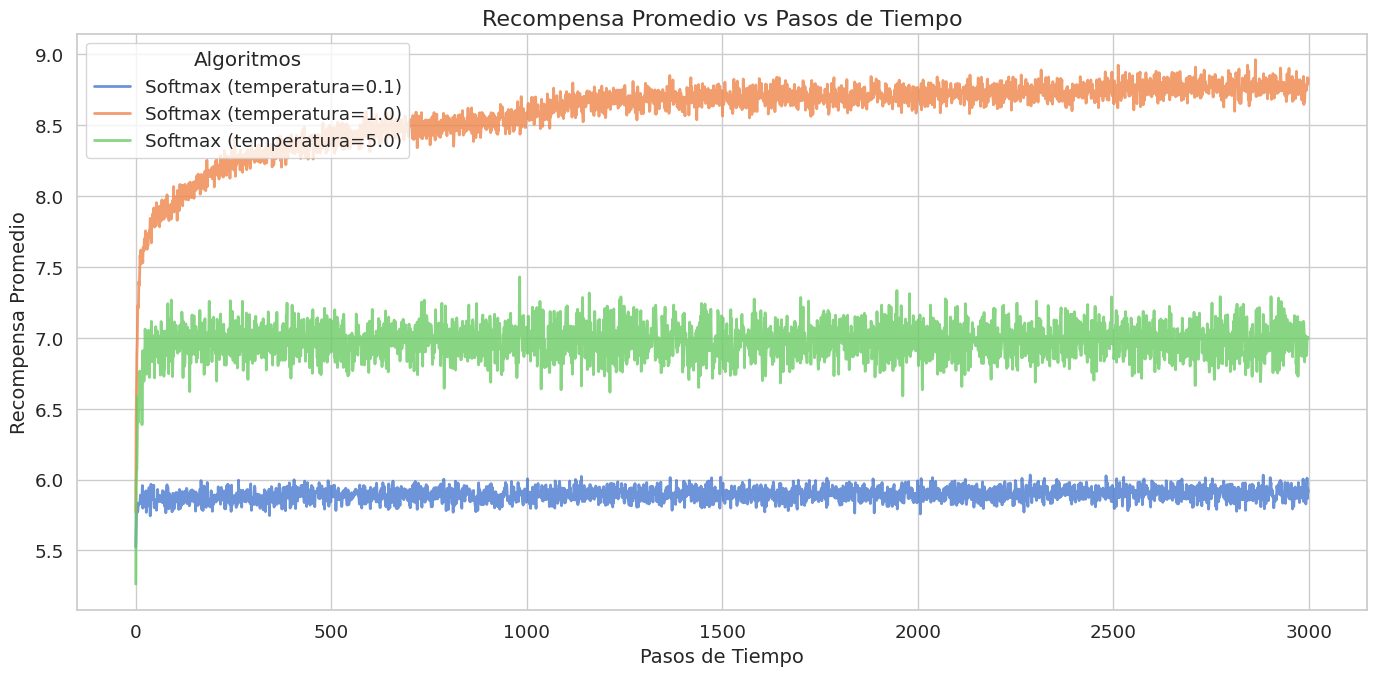

In [4]:
plot_average_rewards(steps, rewards, algorithms)

Esta gráfica muestra la recompensa promedio obtenida por cada algoritmo a lo largo de los 3000 pasos, para cada una de las temperaturas utilizadas. En el eje x se representan los pasos de tiempo, mientras que en el eje y se muestra la recompensa promedio. 

- La línea **azul** corresponde al algoritmo softmax con tau = 0.1, que es el más explotador de los tres. Esto ocurre porque con una temperatura baja, el algoritmo tiende a seleccionar la acción con la mayor recompensa estimada, lo que puede llevar a una rápida convergencia pero también a quedar atrapado en un óptimo local, que es lo que parece estar sucediendo aquí, ya que la recompensa promedio se estabiliza en un valor muy inferior al óptimo. Es un caso similar a un algoritmo greedy puro, que siempre selecciona la acción con la mayor recompensa estimada.
  
- La línea **naranja** corresponde al algoritmo softmax con tau = 1.0, que es un equilibrio entre exploración y explotación. Este algoritmo muestra una recompensa promedio que se acerca al óptimo, aunque no lo alcanza completamente. A medida que pasa el tiempo, la probabilidad del mejor brazo es lo suficientemente alta como para ser seleccionado la mayoría de las veces, pero no tanto como para anular la exploración por completo.
  
- La línea **verde** corresponde al algoritmo softmax con tau = 5.0, que es el más explorador de los tres. Con una temperatura alta, las diferencias entre los valores de recompensa estimados se suavizan demasiado. Aunque el algoritmo sepa que un brazo es mejor (tiene mayor Q), al dividir por 5.0, los exponentes $e^{Q/τ}$ se parecen mucho entre sí.

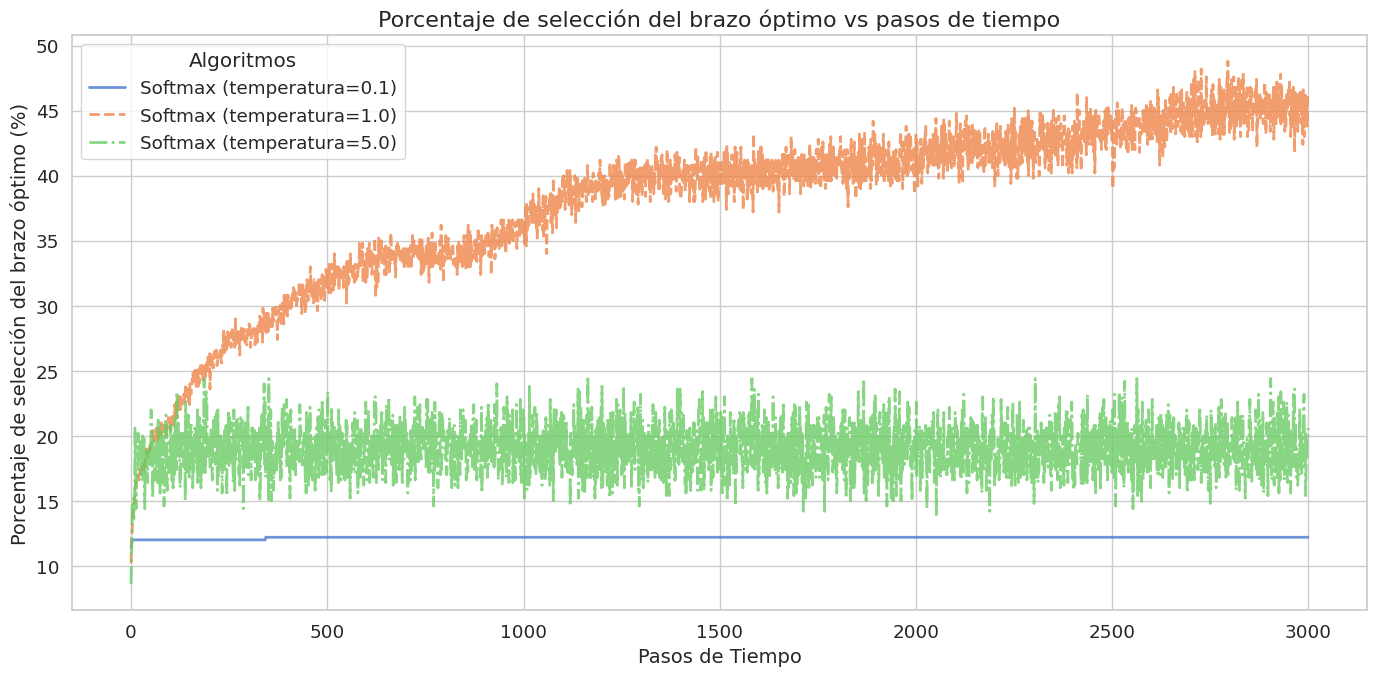

In [5]:
plot_optimal_selections(steps, optimal_selections, algorithms)

En esta gráfica, titulada 'Porcentaje de selección del brazo óptimo vs pasos de tiempo', se muestra el porcentaje de veces que cada algoritmo selecciona el brazo óptimo a lo largo de los 3000 pasos. En el eje x se representan los pasos de tiempo, mientras que en el eje y se muestra el porcentaje de selección del brazo óptimo.

Los resultados son muy similares a los observados en la gráfica de recompensa promedio.
- El algoritmo con tau = 0.1 (línea azul) tiene un porcentaje de selección del brazo óptimo que se estabiliza en un valor muy bajo, lo que indica que se queda atrapado en un óptimo local. 
  
- El algoritmo con tau = 1.0 (línea naranja) muestra una tendencia a aumentar el porcentaje de selección del brazo óptimo a lo largo del tiempo, si bien esta tendencia es muy lenta en comparación con otros algoritmos ya vistos como epsilon-greedy, que en 1000 pasos se estabilizaban por encima del 85% de selección del brazo óptimo. 

- Por último, el algoritmo con tau = 5.0 (línea verde) tiene un porcentaje de selección del brazo óptimo estabilizado alrededor del 20%, lo cual está bastante cerca de ser aleatorio (10% para 10 brazos), lo que confirma que con una temperatura tan alta, el algoritmo no es capaz de distinguir entre los brazos y selecciona casi al azar.

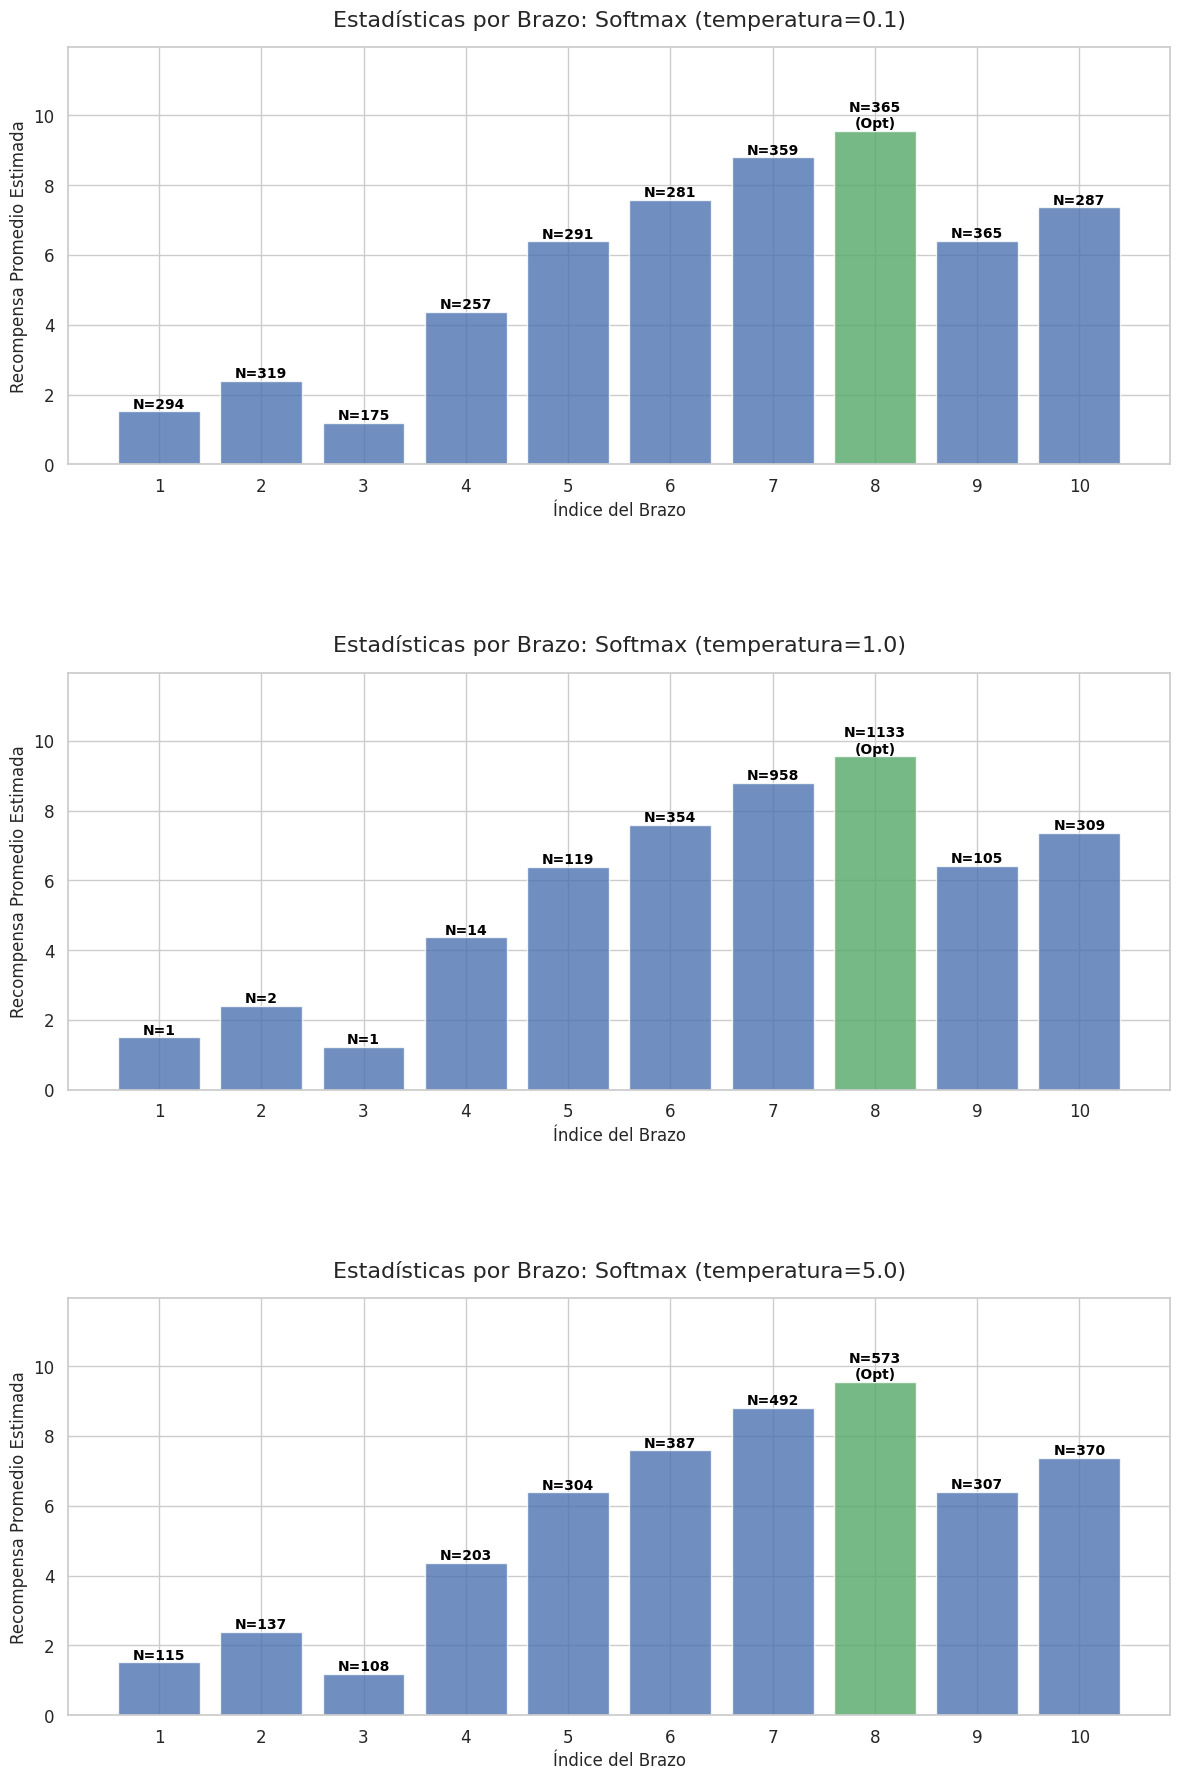

In [6]:
plot_arm_statistics(arms_stats, algorithms, optimal_arm)